In [190]:
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np

In [191]:
prewittX = np.array([
[-1, 0, 1],
[-1, 0, 1],
[-1, 0, 1]
], dtype=np.float32)
prewittY = np.array([
[1, 1, 1],
[0, 0, 0],
[-1, -1, -1]
], dtype=np.float32)
sobelX = np.array([
 [-1, 0, 1],
 [-2, 0, 2],
 [-1, 0, 1]
], dtype=np.float32)
sobelY = np.array([
 [1, 2, 1],
 [0, 0, 0],
 [-1, -2, -1]
], dtype=np.float32)

def convolution(img, kernel):
    size = kernel.shape[0]
    pad_size = size // 2
    padded = np.pad(img, pad_size, mode='constant')
    canvas = np.zeros_like(img).astype(np.float32)
    height, width = img.shape
    for i in range(height):
        for j in range(width):
            region = padded[i:i+size, j:j+size]
            canvas[i, j] = np.sum(region * kernel)
    return canvas
def edge(img, kernelx, kernely):
    gx = convolution(img, kernelx)
    gy = convolution(img, kernely)
    canvas = np.abs(gx) + np.abs(gy)
    canvas = canvas * 255.0 / np.max(canvas)
    return np.clip(canvas, 0, 255).astype(np.uint8)
def threshold(image, value, min_val, max_val):
    img = np.array(image)
    for i in range(img.shape[0]):
        for j in range(img.shape[1]):
            if img[i, j] > value:
                img[i, j] = max_val
            else:
                img[i, j] = min_val 
    return img
def resize(image, new_width, new_height): 
    old_height, old_width = image.shape[:2] 
    resized_image = np.zeros((new_height, new_width), dtype=np.uint8) 
    for i in range(new_height): 
        for j in range(new_width): 
            x = int(j * old_width / new_width) 
            y = int(i * old_height / new_height) 
            resized_image[i, j] = image[y, x] 
    return resized_image 

Text(0.5, 1.0, 'Threshold')

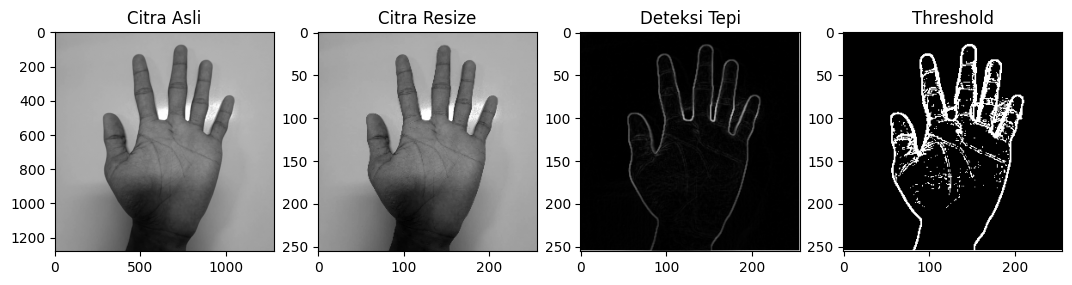

In [192]:
telapak = cv.imread('assets/telapak.jpeg')
telapakG = cv.cvtColor(telapak, cv.COLOR_BGR2GRAY)
telapakR = resize(telapakG, 256, 256)
telapakDT = edge(telapakR, prewittX, prewittY)
telapakT = threshold(telapakDT, 12, 0, 255)

plt.figure(figsize = (13, 8))

plt.subplot(1, 4, 1)
plt.imshow(telapakG, cmap = 'gray')
plt.title('Citra Asli')

plt.subplot(1, 4, 2)
plt.imshow(telapakR, cmap = 'gray')
plt.title('Citra Resize')

plt.subplot(1, 4, 3)
plt.imshow(telapakDT, cmap = 'gray')
plt.title('Deteksi Tepi')

plt.subplot(1, 4, 4)
plt.imshow(telapakT, cmap = 'gray')
plt.title('Threshold')

In [193]:
kernel_diamond = np.array([ 
    [0,0,1,0,0], 
    [0,1,1,1,0], 
    [1,1,1,1,1], 
    [0,1,1,1,0], 
    [0,0,1,0,0] 
]) 
 
kernel_cross = np.array([ 
    [0,1,0], 
    [1,1,1], 
    [0,1,0] 
]) 
 
kernel_x = np.array([ 
    [1,0,0,0,1], 
    [0,1,0,1,0], 
    [0,0,1,0,0], 
    [0,1,0,1,0], 
    [1,0,0,0,1] 
], dtype=np.uint8)

kernel3f1 = np.array([
    [1, 1, 1],
    [1, 1, 1],
    [1, 1, 1]
])

kernel5f1 = np.array([ 
    [1,1,1,1,1], 
    [1,1,1,1,1], 
    [1,1,1,1,1], 
    [1,1,1,1,1], 
    [1,1,1,1,1] 
]) 

In [194]:
def dilasi(image,kernel): 
    height, width = image.shape 
    k_height, k_width = kernel.shape 
    center = k_height // 2 
    hasil = np.zeros((height, width)) 
    for i in range(center, height-center): 
        for j in range(center, width-center): 
            if image[i,j] == 255: 
                for k in range(k_height): 
                    for l in range(k_width): 
                        if kernel[k,l] == 1: 
                            hasil[i+k-center,j+l-center] =255 
            else: 
                if hasil[i,j] !=255: 
                    hasil[i,j] = 0  
    return hasil 

def erosi(image, kernel): 
    height, width = image.shape
    k_height, k_width = kernel.shape
    center = k_height // 2
    hasil = np.zeros((height, width))
    for i in range(center, height - center):
        for j in range(center, width - center):
            cocok = True
            for k in range(k_height): 
                for l in range(k_width): 
                    if kernel[k, l] == 1 and image[i + k - center, j + l - center] == 0: 
                        cocok = False 
                        break 
                if not cocok: 
                    break 
            if cocok: 
                hasil[i, j] = 255 
    return hasil

def opening(image_erosi, kernel):
    hasil = dilasi(image_erosi, kernel)
    return hasil

def closing(image_dilasi, kernel):
    hasil = erosi(image_dilasi, kernel)
    return hasil

def thinning(img): 
    binary = (img > 0).astype(np.uint8) 
    height, width = binary.shape 
    changed = True 
    while changed: 
        changed = False 
        hapus = [] 
        # STEP 1 
        for i in range(1, height-1): 
            for j in range(1, width-1): 
                P1 = binary[i, j] 
                if P1 != 1: 
                    continue 
                P2 = binary[i-1, j] 
                P3 = binary[i-1, j+1] 
                P4 = binary[i, j+1] 
                P5 = binary[i+1, j+1] 
                P6 = binary[i+1, j] 
                P7 = binary[i+1, j-1] 
                P8 = binary[i, j-1] 
                P9 = binary[i-1, j-1] 
                tetangga = [P2,P3,P4,P5,P6,P7,P8,P9] 
                jumlah = np.sum(tetangga) 
                transisi = 0 
                urutan = tetangga + [P2] 
                for k in range(8): 
                    if urutan[k] == 0 and urutan[k+1] == 1: 
                        transisi += 1 
                if ( 
                    2 <= jumlah <= 6 and 
                    transisi == 1 and 
                    P2 * P4 * P6 == 0 and 
                    P4 * P6 * P8 == 0 
                ):
                     hapus.append((i,j)) 
        if hapus: 
            changed = True 
            for i,j in hapus: 
                binary[i,j] = 0 
        hapus = [] 
        # STEP 2 
        for i in range(1, height-1): 
            for j in range(1, width-1): 
 
                P1 = binary[i, j] 
                if P1 != 1: 
                    continue 
                P2 = binary[i-1, j] 
                P3 = binary[i-1, j+1] 
                P4 = binary[i, j+1] 
                P5 = binary[i+1, j+1] 
                P6 = binary[i+1, j] 
                P7 = binary[i+1, j-1] 
                P8 = binary[i, j-1] 
                P9 = binary[i-1, j-1] 
                tetangga = [P2,P3,P4,P5,P6,P7,P8,P9] 
                jumlah = np.sum(tetangga) 
                transisi = 0 
                urutan = tetangga + [P2] 
                for k in range(8): 
                    if urutan[k] == 0 and urutan[k+1] == 1: 
                        transisi += 1 
 
                if ( 
                    2 <= jumlah <= 6 and 
                    transisi == 1 and 
                    P2 * P4 * P8 == 0 and 
                    P2 * P6 * P8 == 0 
                ): 
                    hapus.append((i,j)) 
        if hapus: 
            changed = True 
            for i,j in hapus: 
                binary[i,j] = 0 
    return binary * 255

def thickening(img, kernel, iterasi=1): 
    hasil = img.copy() 
    for _ in range(iterasi): 
        hasil = dilasi(hasil, kernel) 
    return hasil

def gradientMorph(erosi, dilasi):
    hasil = dilasi - erosi
    return hasil

(np.float64(-0.5), np.float64(255.5), np.float64(255.5), np.float64(-0.5))

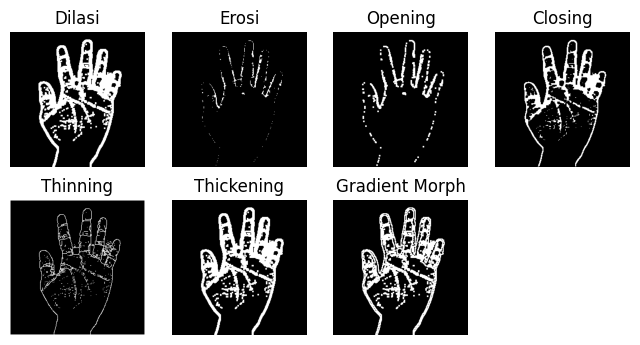

In [195]:
telapakDilasi = dilasi(telapakT, kernel3f1)
telapakErosi = erosi(telapakT, kernel3f1)
telapakOpening = opening(telapakErosi, kernel3f1)
telapakClosing = closing(telapakDilasi, kernel3f1)
telapakThinning = thinning(telapakT)
telapakThickening = thickening(telapakT, kernel3f1)
telapakGM = gradientMorph(telapakErosi, telapakDilasi)

plt.figure(figsize=(8, 4))

plt.subplot(2, 4, 1)
plt.imshow(telapakDilasi, cmap = 'gray')
plt.title('Dilasi')
plt.axis('off')

plt.subplot(2, 4, 2)
plt.imshow(telapakErosi, cmap = 'gray')
plt.title('Erosi')
plt.axis('off')

plt.subplot(2, 4, 3)
plt.imshow(telapakOpening, cmap = 'gray')
plt.title('Opening')
plt.axis('off')

plt.subplot(2, 4, 4)
plt.imshow(telapakClosing, cmap = 'gray')
plt.title('Closing')
plt.axis('off')

plt.subplot(2, 4, 5)
plt.imshow(telapakThinning, cmap = 'gray')
plt.title('Thinning')
plt.axis('off')

plt.subplot(2, 4, 6)
plt.imshow(telapakThickening, cmap = 'gray')
plt.title('Thickening')
plt.axis('off')

plt.subplot(2, 4, 7)
plt.imshow(telapakGM, cmap = 'gray')
plt.title('Gradient Morph')
plt.axis('off')

(np.float64(-0.5), np.float64(255.5), np.float64(255.5), np.float64(-0.5))

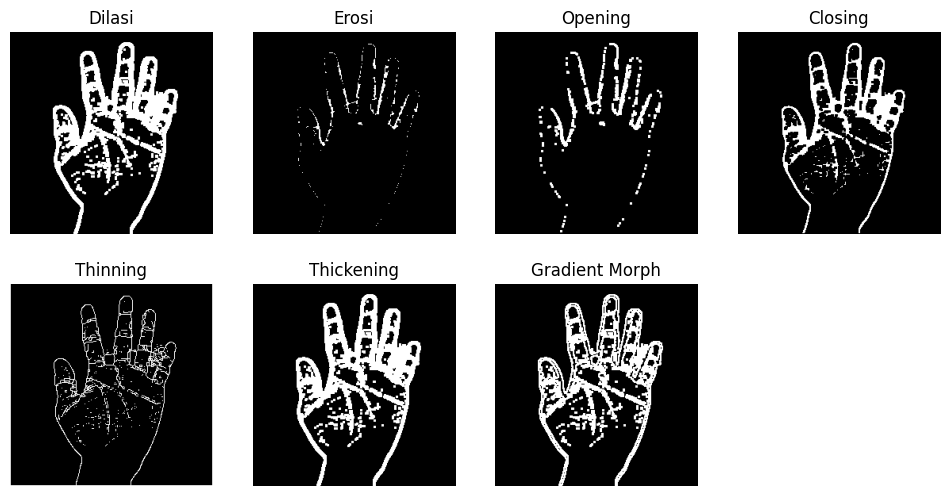

In [196]:
telapakDilasi2 = dilasi(telapakT, kernel5f1)
telapakErosi2 = erosi(telapakT, kernel5f1)
telapakOpening2 = opening(telapakErosi2, kernel5f1)
telapakClosing2 = closing(telapakDilasi2, kernel5f1)
telapakThinning2 = thinning(telapakT)
telapakThickening2 = thickening(telapakT, kernel5f1)
telapakGM2 = gradientMorph(telapakErosi2, telapakDilasi2)

plt.figure(figsize=(12, 6))

plt.subplot(2, 4, 1)
plt.imshow(telapakDilasi, cmap = 'gray')
plt.title('Dilasi')
plt.axis('off')

plt.subplot(2, 4, 2)
plt.imshow(telapakErosi, cmap = 'gray')
plt.title('Erosi')
plt.axis('off')

plt.subplot(2, 4, 3)
plt.imshow(telapakOpening, cmap = 'gray')
plt.title('Opening')
plt.axis('off')

plt.subplot(2, 4, 4)
plt.imshow(telapakClosing, cmap = 'gray')
plt.title('Closing')
plt.axis('off')

plt.subplot(2, 4, 5)
plt.imshow(telapakThinning, cmap = 'gray')
plt.title('Thinning')
plt.axis('off')

plt.subplot(2, 4, 6)
plt.imshow(telapakThickening, cmap = 'gray')
plt.title('Thickening')
plt.axis('off')

plt.subplot(2, 4, 7)
plt.imshow(telapakGM, cmap = 'gray')
plt.title('Gradient Morph')
plt.axis('off')

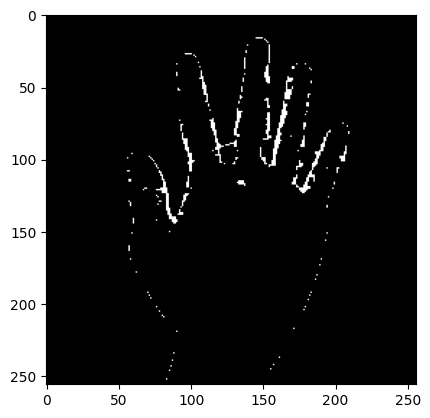

In [197]:
telapakD = dilasi(telapakT, kernel3f1)
telapakE = erosi(telapakT, kernel3f1)
telapakO = opening(telapakE, kernel3f1)
telapakOC = closing(telapakO, kernel3f1)

plt.imshow(telapakOC, cmap = 'gray')
plt.show()

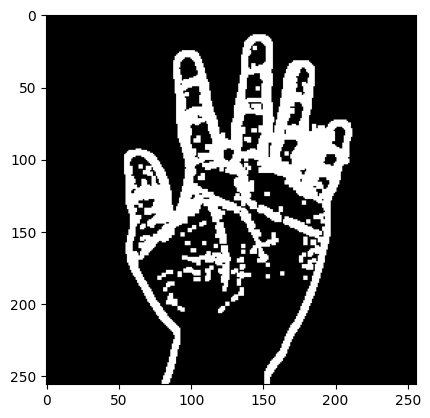

In [198]:
telapakD = dilasi(telapakT, kernel3f1)
telapakE = erosi(telapakT, kernel3f1)
telapakC = closing(telapakD, kernel3f1)
telapakCO = opening(telapakC, kernel3f1)

plt.imshow(telapakCO, cmap = 'gray')
plt.show()

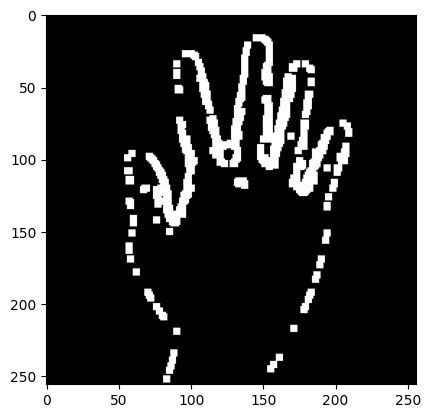

In [199]:
telapakD = dilasi(telapakT, kernel3f1)
telapakE = erosi(telapakT, kernel3f1)
telapakO = opening(telapakE, kernel3f1)
telapakOD = dilasi(telapakO, kernel3f1)

plt.imshow(telapakOD, cmap = 'gray')
plt.show()

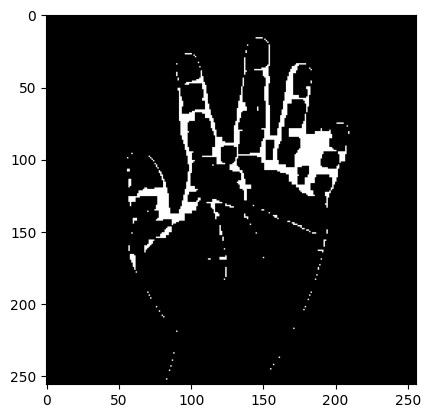

In [200]:
telapakD = dilasi(telapakT, kernel3f1)
telapakE = erosi(telapakT, kernel3f1)
telapakC = closing(telapakD, kernel3f1)
telapakCE = erosi(telapakC, kernel3f1)

plt.imshow(telapakCE, cmap = 'gray')
plt.show()

(np.float64(-0.5), np.float64(255.5), np.float64(255.5), np.float64(-0.5))

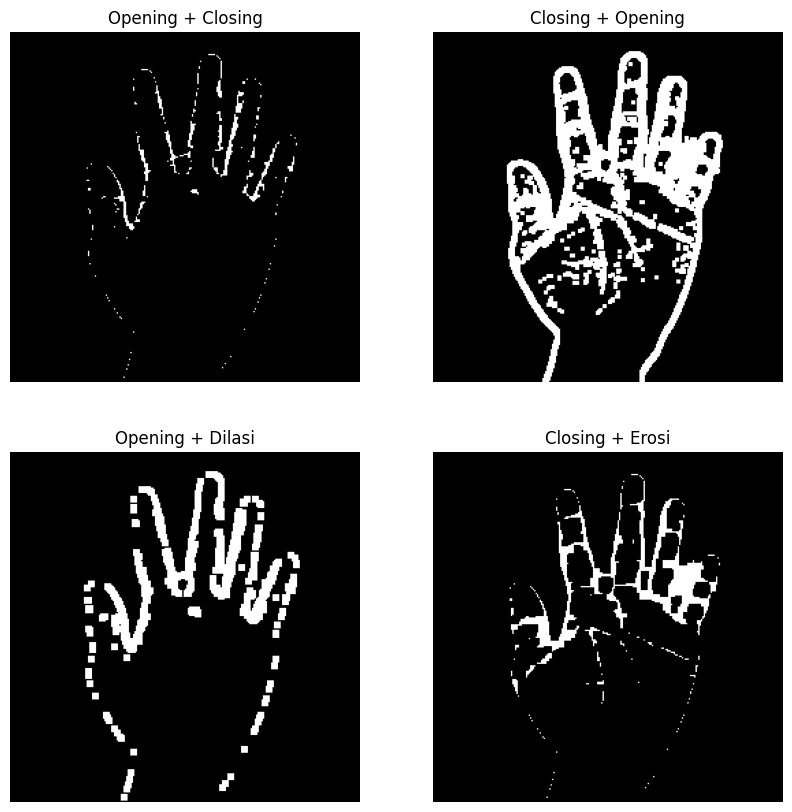

In [201]:
plt.figure(figsize = (10, 10))

plt.subplot(2, 2, 1)
plt.imshow(telapakOC, cmap = 'gray')
plt.title('Opening + Closing')
plt.axis('off')

plt.subplot(2, 2, 2)
plt.imshow(telapakCO, cmap = 'gray')
plt.title('Closing + Opening')
plt.axis('off')

plt.subplot(2, 2, 3)
plt.imshow(telapakOD, cmap = 'gray')
plt.title('Opening + Dilasi')
plt.axis('off')

plt.subplot(2, 2, 4)
plt.imshow(telapakCE, cmap = 'gray')
plt.title('Closing + Erosi')
plt.axis('off')

In [202]:
def filter(img, size, mode):
    height, width = img.shape
    pad = size // 2
    padded = np.pad(img, pad, mode='edge')
    canvas = np.zeros_like(img, dtype=np.uint8)
    
    match mode:
        case 'mean':
            area = size * size
            for i in range(height):
                for j in range(width):
                    region = padded[i:i+size, j:j+size]
                    total = 0
                    for val in region.ravel():
                        total += val
                    canvas[i, j] = total // area
        case 'median':
            for i in range(height):
                for j in range(width):
                    region = padded[i:i+size, j:j+size]
                    values = region.ravel().tolist()
                    values.sort()
                    n = len(values)
                    mid = n // 2
                    if n % 2 == 1:
                        median_val = values[mid]
                    else:
                        median_val = (values[mid - 1] + values[mid]) // 2
                    canvas[i, j] = median_val
        case 'modus':
            for i in range(height):
                for j in range(width):
                    region = padded[i:i+size, j:j+size]
                    values = region.ravel()
                    count = {}
                    for val in values:
                        if val in count:
                            count[val] += 1
                        else:
                            count[val] = 1
                    max_count = 0
                    mode_val = 0
                    for val, freq in count.items():
                        if freq > max_count:
                            max_count = freq
                            mode_val = val
                    canvas[i, j] = mode_val
    return canvas

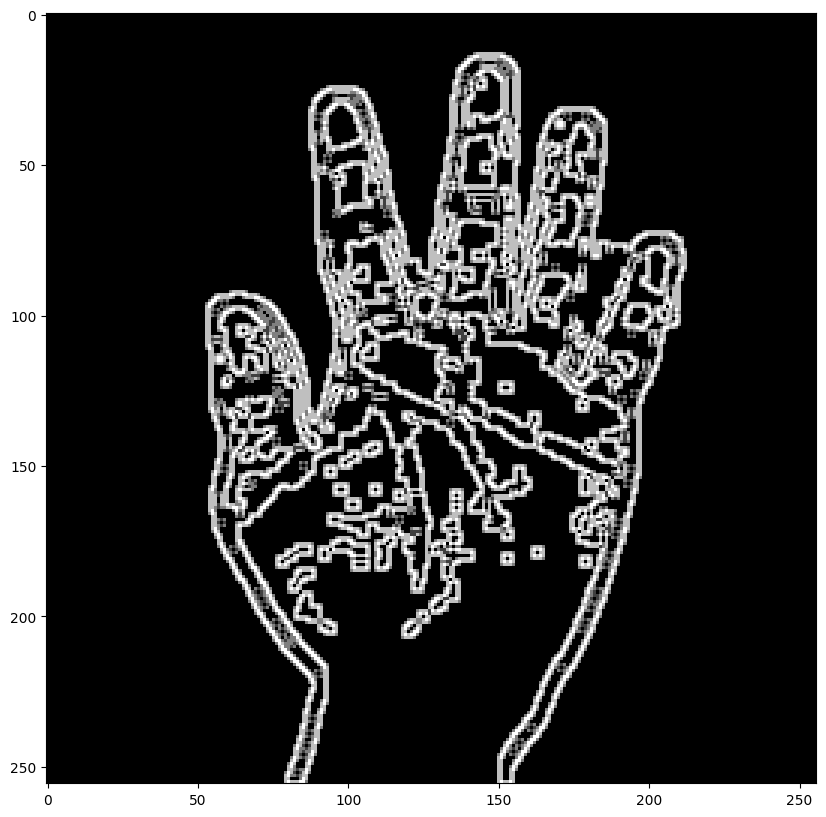

In [209]:
def tepi_gradient_dasar(image, kernel):
    d = dilasi(image, kernel).astype(np.int16)
    e = erosi(image, kernel).astype(np.int16)
    return np.clip(d - e, 0, 255).astype(np.uint8)
 
kernelSharpening = np.array([
[1/9, 1/9, 1/9],
[1/9, 8/9, 1/9],
[1/9, 1/9, 1/9]
])
kernelSmoothing = np.array([
[1/10, 1/10, 1/10],
[1/10, 1/5, 1/10],
[1/10, 1/10, 1/10]
])

telapak1 = tepi_gradient_dasar(telapakT, kernel3f1)
telapak2 = edge(telapak1, prewittX, prewittY)

plt.figure(figsize = (10, 10))
plt.imshow(telapak2, cmap = 'gray')